# Symbulate Graphics Gallery

A single reference for Symbulate's plotting: every 1D and 2D plot type with its
default and alternatives, the overlay mechanism, marginal plots, jitter modes,
plots of three or more variables, and the theoretical-distribution features
(`cdf=True`, the self-framing window, `shade()`).

Each plot of *simulated data* has a **default** type chosen from the data, plus
**alternatives** you select with `type=`. When you call `.plot()` without a type,
a message names the default and lists the alternatives — that is what documents
the choices below. (Pass `suggest=False` to silence it, `suggest=True` to force it.)

In [1]:
from symbulate import *

---
## 1D plot types

### Discrete data, large n — default: **impulse**
The message below names the default and the alternatives (`type='hist'`, etc.).

Currently Showing: Impulse Plot (Default)
Alternative Plots: Histogram (type = "hist"), Dot Plot (type = "dotplot"), ECDF Plot (type = "ecdf")


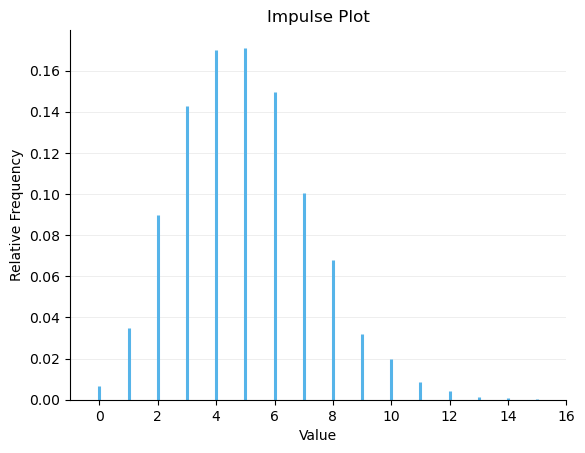

In [2]:
RV(Poisson(5)).sim(10000).plot(suggest=True)

Alternatives — histogram and ECDF:

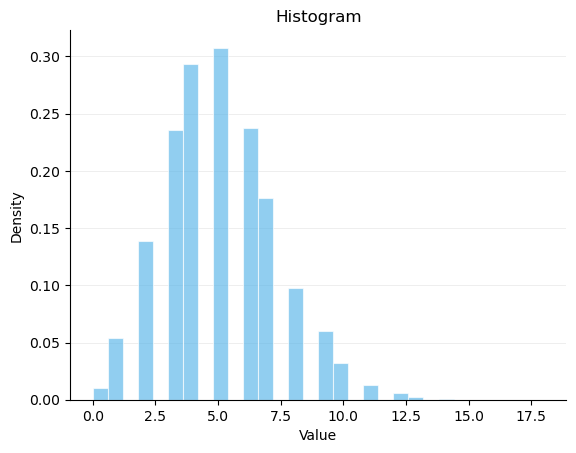

In [3]:
RV(Poisson(5)).sim(10000).plot(type='hist')

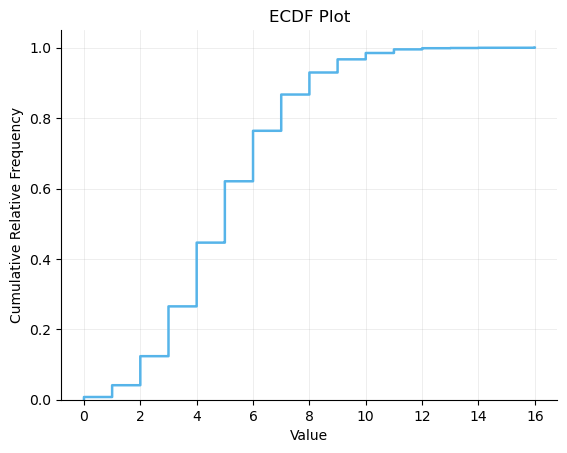

In [4]:
RV(Poisson(5)).sim(10000).plot(type='ecdf', suggest=False)

### Discrete data, small n — default: **dot plot**

Currently Showing: Dot Plot (Default)
Alternative Plots: Impulse Plot (type = "impulse"), Histogram (type = "hist"), ECDF Plot (type = "ecdf")


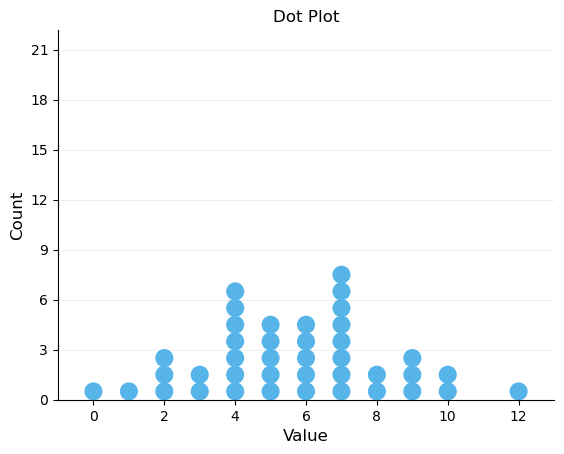

In [5]:
RV(Poisson(5)).sim(40).plot(suggest=True)

### Continuous data, large n — default: **histogram**

Currently Showing: Histogram (Default)
Alternative Plots: Rug Plot (type = "rug"), Density (Estimated) (type = "density"), Box Plot (type = "box"), Violin Plot (type = "violin"), ECDF Plot (type = "ecdf")


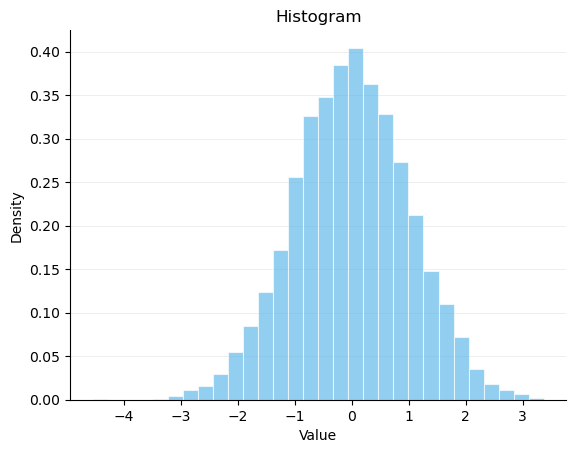

In [6]:
RV(Normal(0, 1)).sim(10000).plot(suggest=True)

Alternatives — density, box, and violin:

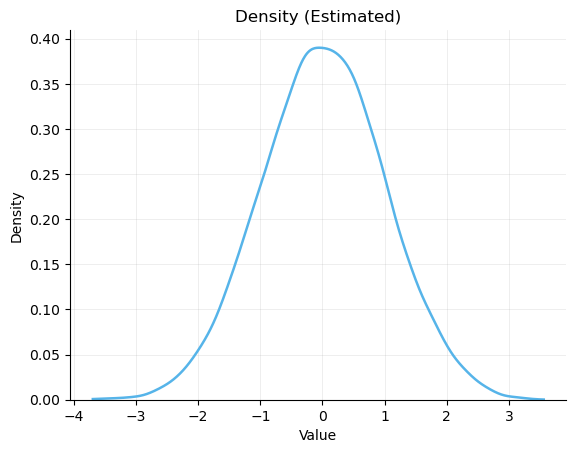

In [7]:
RV(Normal(0, 1)).sim(10000).plot(type='density', suggest=False)

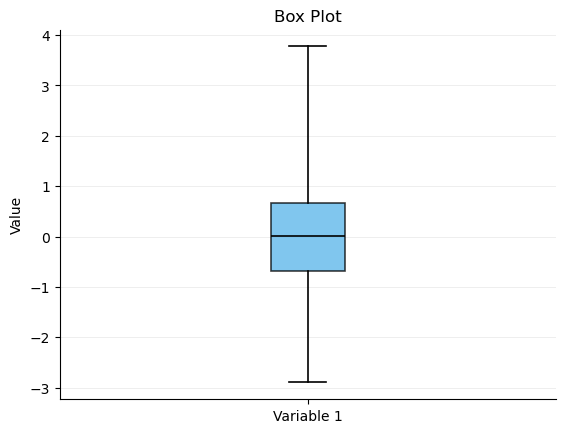

In [8]:
RV(Normal(0, 1)).sim(2000).plot(type='box', suggest=False)

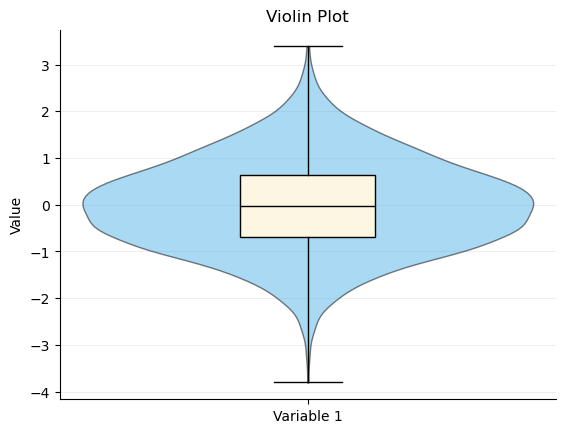

In [9]:
RV(Normal(0, 1)).sim(2000).plot(type='violin', suggest=False)

### Continuous data, small n — default: **rug plot**

Currently Showing: Rug Plot (Default)
Alternative Plots: Histogram (type = "hist"), Density (Estimated) (type = "density"), Box Plot (type = "box"), Violin Plot (type = "violin"), ECDF Plot (type = "ecdf")


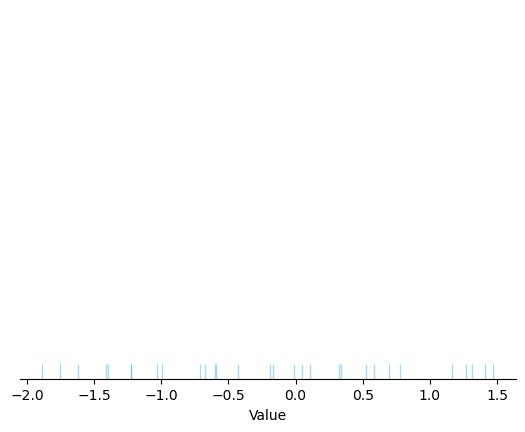

In [10]:
RV(Normal(0, 1)).sim(30).plot(suggest=True)

### Categorical data — default: **bar** (large n) / **dot plot** (small n)

Currently Showing: Bar Chart (Default)
Alternative Plots: Dot Plot (type = "dotplot"), Impulse Plot (type = "impulse")


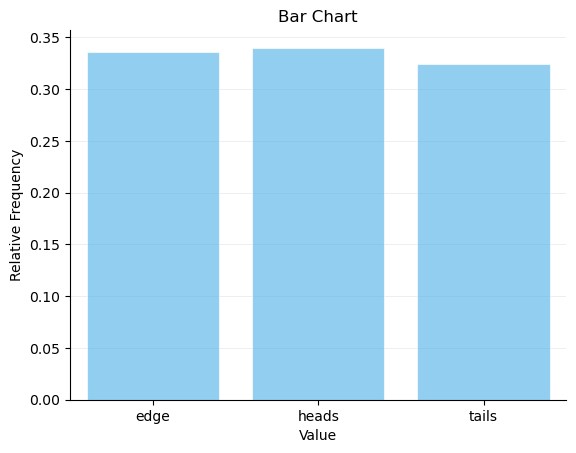

In [11]:
RV(BoxModel(['heads', 'tails', 'edge'])).sim(500).plot(suggest=True)

---
## 2D plot types

### Discrete × discrete — **scatter** (small n), **tile** (large n), **mosaic**

Currently Showing: Scatter Plot (Default)
Alternative Plots: Tile Plot (type = "tile"), Mosaic Plot (type = "mosaic"), Stacked Bar Chart (type = "stackedbar")
Currently Using: jitter="spiral" (points sharing a value form a tight, countable cluster)
Other Jitter Options: jitter="bins" (points sharing a value fill that value's box, like a tiny dot histogram), jitter="random" (small random noise), jitter=False (exact positions -- repeated points draw on top of each other)


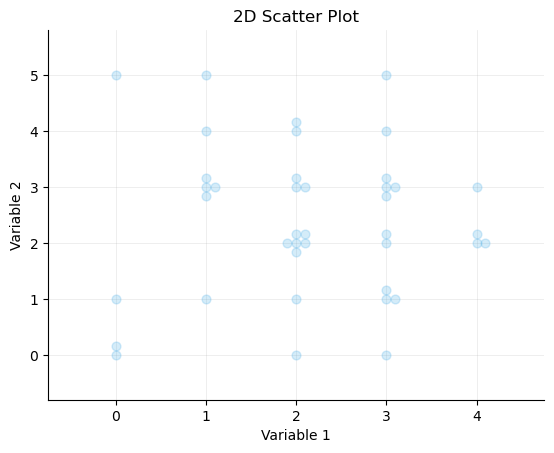

In [12]:
RV(Binomial(5, 0.4) ** 2).sim(40).plot(suggest=True)

Currently Showing: Tile Plot (Default)
Alternative Plots: Scatter Plot (type = "scatter"), Mosaic Plot (type = "mosaic"), Stacked Bar Chart (type = "stackedbar")


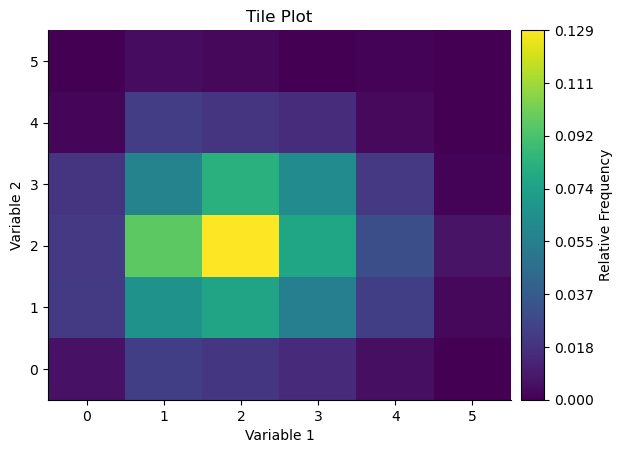

In [13]:
RV(Binomial(5, 0.4) ** 2).sim(2000).plot(suggest=True)

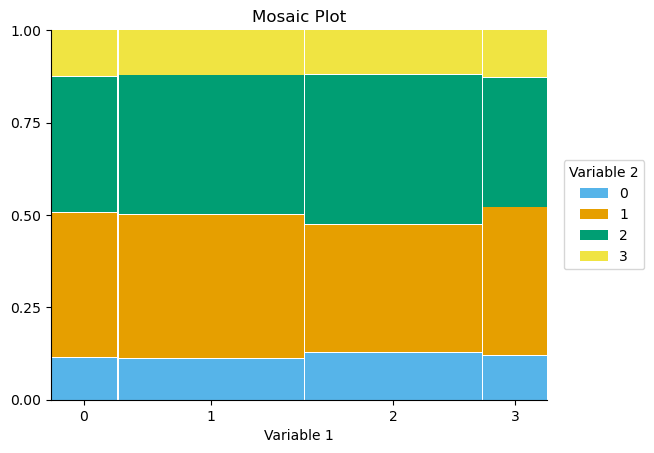

In [14]:
RV(Binomial(3, 0.5) ** 2).sim(2000).plot(type='mosaic', suggest=False)

The **stacked bar chart** is now its own plot type, `type='stackedbar'` (it used to be `type='mosaic', equal_width=True`). Every column is the same width, so the segments show each x-value's conditional distribution as a 100%-stacked bar rather than scaling column width by frequency. Symbulate picks between the two by how many categories there are -- over four on either axis gets the stacked bar, so this example uses `Binomial(6, 0.4)` (7 values).

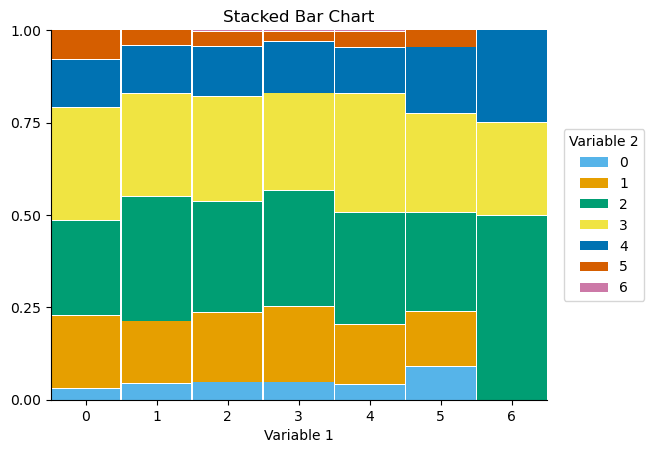

In [15]:
RV(Binomial(6, 0.4) ** 2).sim(2000).plot(type='stackedbar', suggest=False)

### Continuous × continuous — **scatter** (small n), **2D histogram** (large n), **2D density**

A 2-D density is drawn as discrete **contour bands** with thin outlines, so a band can be
matched to the colorbar by eye — hence the "Contour Plot" title. Pass `contour=False` for
one smooth gradient instead.

Currently Showing: Joint Histogram (Default)
Alternative Plots: Joint Density (Estimated) (type = "density2d"), Scatter Plot (type = "scatter")


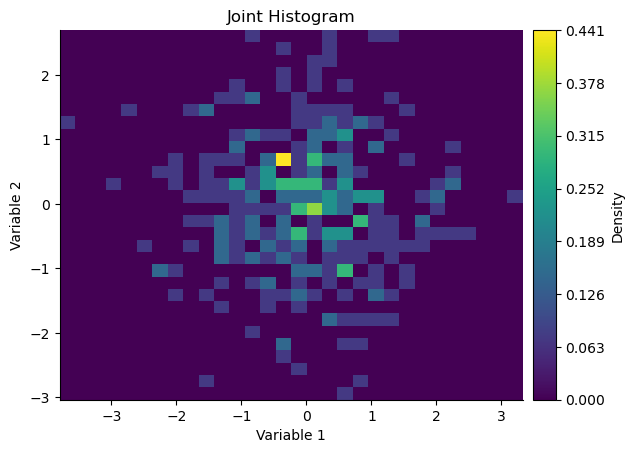

In [16]:
RV(Normal(0, 1) ** 2).sim(300).plot(suggest=True)

Currently Showing: Joint Histogram (Default)
Alternative Plots: Joint Density (Estimated) (type = "density2d"), Scatter Plot (type = "scatter")


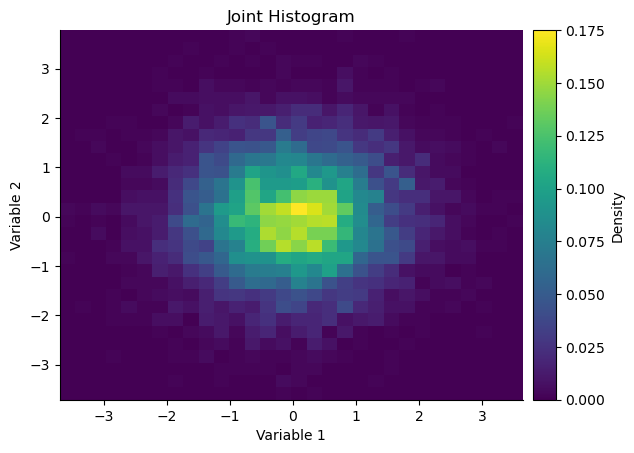

In [17]:
RV(Normal(0, 1) ** 2).sim(10000).plot(suggest=True)

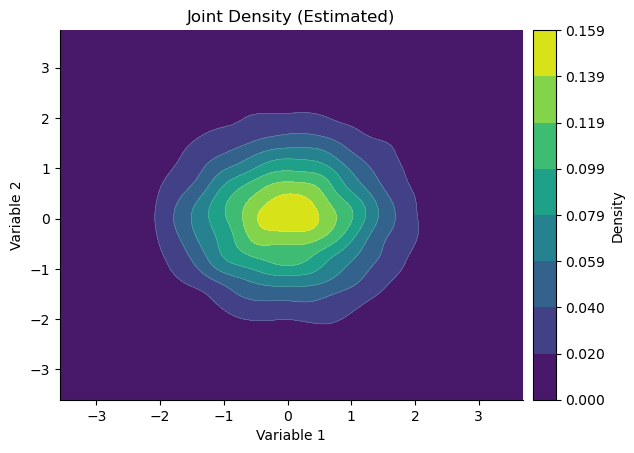

In [18]:
RV(Normal(0, 1) ** 2).sim(10000).plot(type='density2d', suggest=False)

### Mixed discrete × continuous — **segmented** plots (small n), **box/violin/tile** (large n)
The short names `rug`/`density`/`hist` resolve to their segmented forms on mixed data.

Currently Showing: Rug Plot (Default)
Alternative Plots: Tile Plot (type = "tile"), Box Plot (type = "box"), Violin Plot (type = "violin"), Density (Estimated) (type = "density"), Histogram (type = "hist")


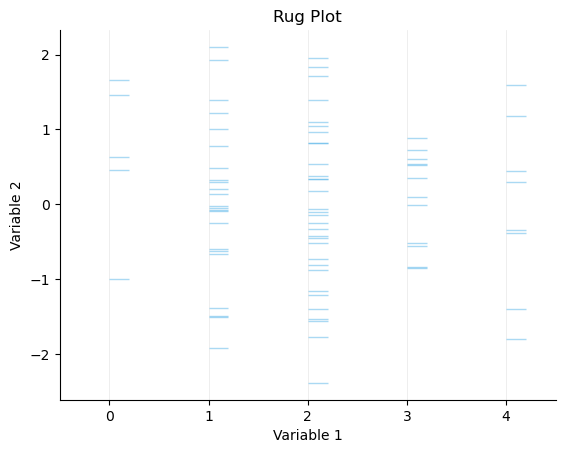

In [19]:
RV(Binomial(5, 0.4) * Normal(0, 1)).sim(80).plot(suggest=True)

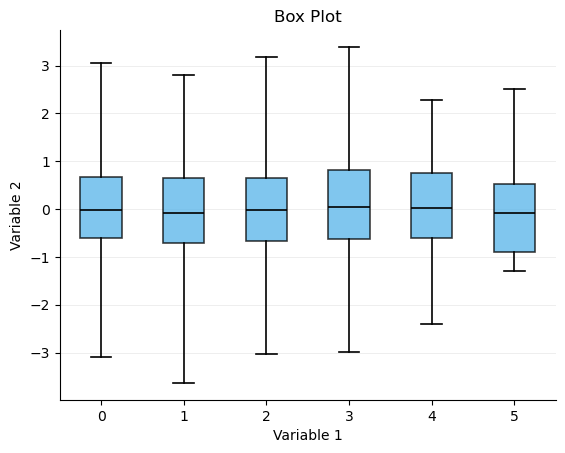

In [20]:
RV(Binomial(5, 0.4) * Normal(0, 1)).sim(2000).plot(type='box', suggest=False)

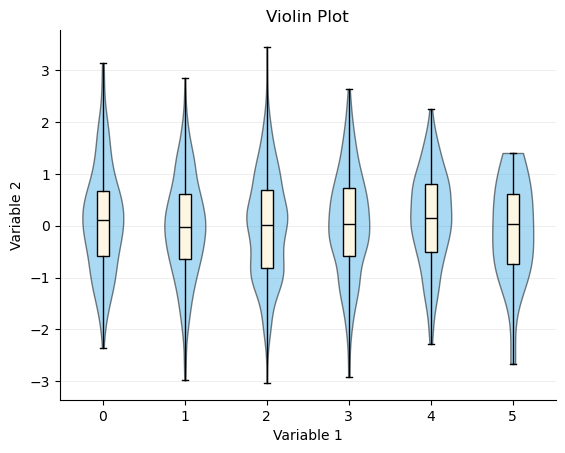

In [21]:
RV(Binomial(5, 0.4) * Normal(0, 1)).sim(2000).plot(type='violin', suggest=False)

---
## Overlay: simulated + theoretical
Two `.plot()` calls in one cell draw on the same axes. A simulated histogram with
its theoretical pmf overlaid:

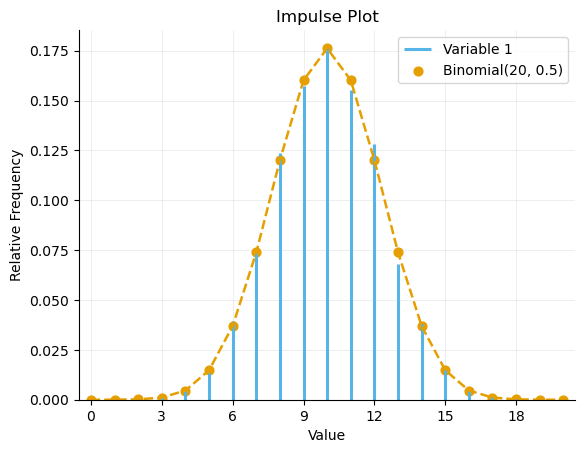

In [22]:
RV(Binomial(20, 0.5)).sim(10000).plot(suggest=False)
Binomial(20, 0.5).plot()

### Multiple series
Different batches of data get distinct colors automatically.

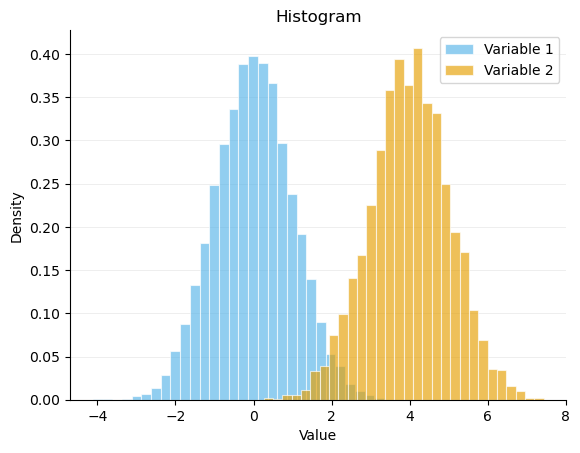

In [23]:
RV(Normal(0, 1)).sim(5000).plot(suggest=False)
RV(Normal(4, 1)).sim(5000).plot(suggest=False)

---
## Marginal plots
Add `marginal=True` to a 2D plot for aligned marginal panels on each axis: each one shows
that variable's own distribution, drawn the way a plot of it alone would be. The three
panels fill the figure, so such a plot can't be overlaid with another — which is why it
stays opt-in.

(A *distribution's* two-variable plot always shows these strips and takes no such
keyword; see "Two variables, exactly" below.)

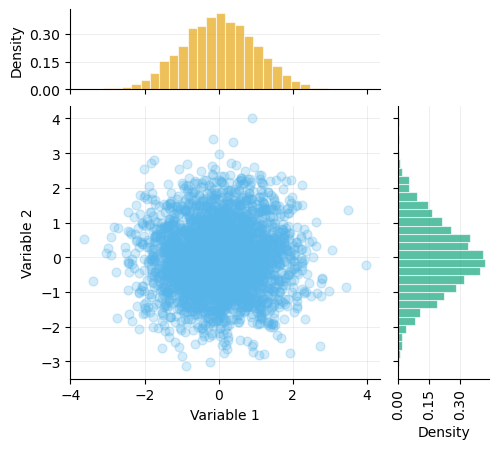

In [24]:
RV(Normal(0, 1) ** 2).sim(3000).plot(type='scatter', marginal=True, suggest=False)

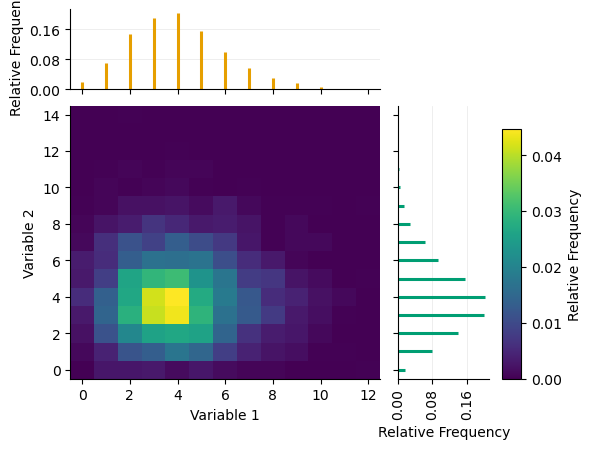

In [25]:
RV(Poisson(4) ** 2).sim(3000).plot(type='tile', marginal=True, suggest=False)

---
## Three or more variables — default: **pairs matrix**
No single plot shows three variables at once, so `.plot()` draws a matrix: each variable's
own distribution down the diagonal, each pair's joint distribution below it, and each joint
panel's colorbar in the empty cell mirroring it. Every panel is chosen exactly as a plot of
that data alone would be, and a column is one variable at one scale, so it reads straight
down.

Currently Showing: Pairs Plot (Default)
Alternative Plots: Path Plot (type = "path")


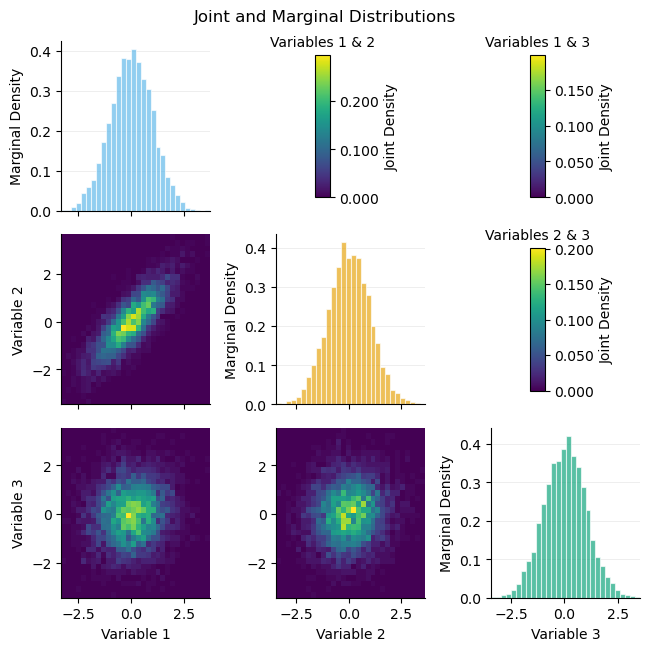

In [26]:
RV(MultivariateNormal(mean=[0, 0, 0],
                      cov=[[1.0, 0.8, 0.1],
                           [0.8, 1.0, 0.1],
                           [0.1, 0.1, 1.0]])).sim(5000).plot(suggest=True)

`bins=` sets the bin count for the whole matrix, diagonal included, and
`normalize=False` switches it to raw counts.

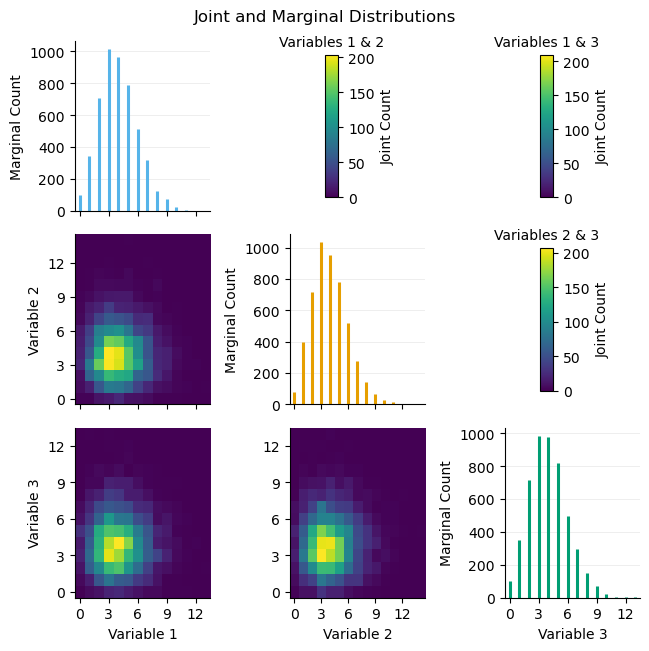

In [27]:
RV(Poisson(4) ** 3).sim(5000).plot(normalize=False, suggest=False)

`type="path"` is the alternative: one connected line per realization against its
index. Index ticks are whole numbers, since there is nothing between one position and
the next.

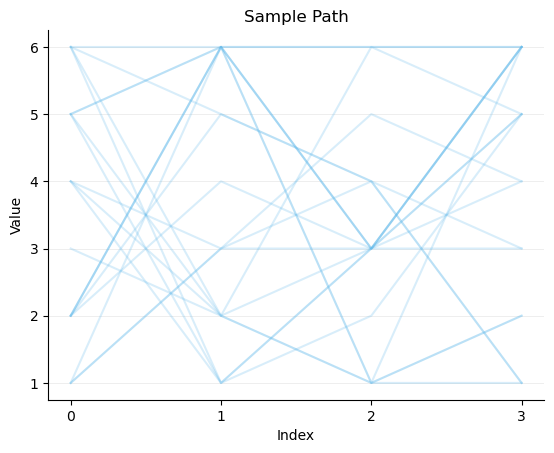

In [28]:
RV(BoxModel([1, 2, 3, 4, 5, 6], size=4)).sim(20).plot(type='path', suggest=False)

---
## Jitter modes (discrete 2D scatter)
When many points share a value, `jitter=` controls how they spread apart. The note
under the plot lists the options.

Currently Showing: Scatter Plot
Alternative Plots: Tile Plot (Default), Mosaic Plot (type = "mosaic"), Stacked Bar Chart (type = "stackedbar")
Currently Using: jitter="spiral" (points sharing a value form a tight, countable cluster)
Other Jitter Options: jitter="bins" (points sharing a value fill that value's box, like a tiny dot histogram), jitter="random" (small random noise), jitter=False (exact positions -- repeated points draw on top of each other)


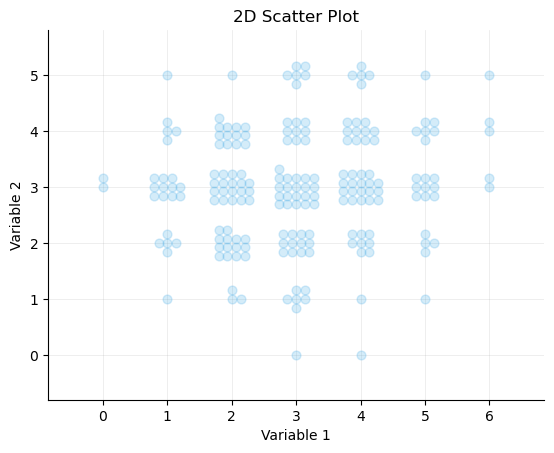

In [29]:
RV(Binomial(6, 0.5) ** 2).sim(200).plot(type='scatter', jitter='spiral', suggest=True)

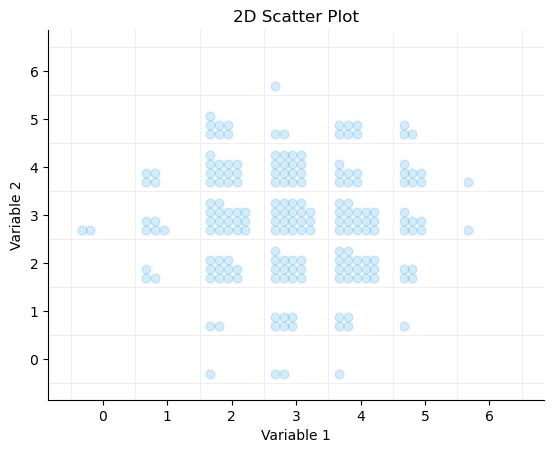

In [30]:
RV(Binomial(6, 0.5) ** 2).sim(200).plot(type='scatter', jitter='bins', suggest=False)

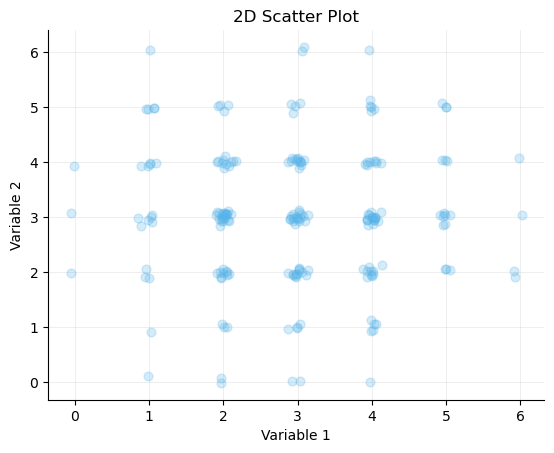

In [31]:
RV(Binomial(6, 0.5) ** 2).sim(200).plot(type='scatter', jitter='random', suggest=False)

---
## Theoretical distribution plots

### pmf / pdf and CDF
A distribution's `.plot()` draws the pmf/pdf; `cdf=True` draws the CDF.

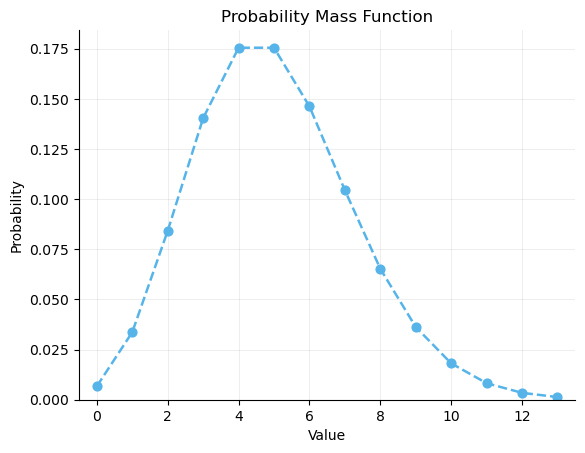

In [32]:
Poisson(5).plot()

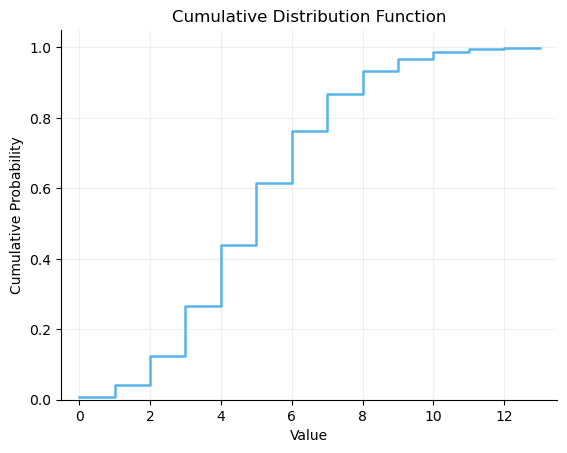

In [33]:
Poisson(5).plot(cdf=True)

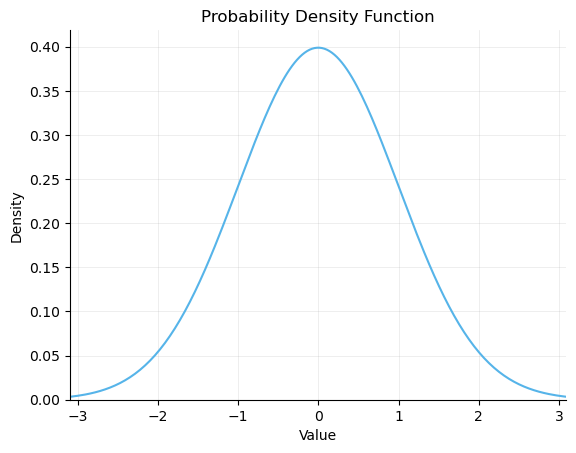

In [34]:
Normal(0, 1).plot()

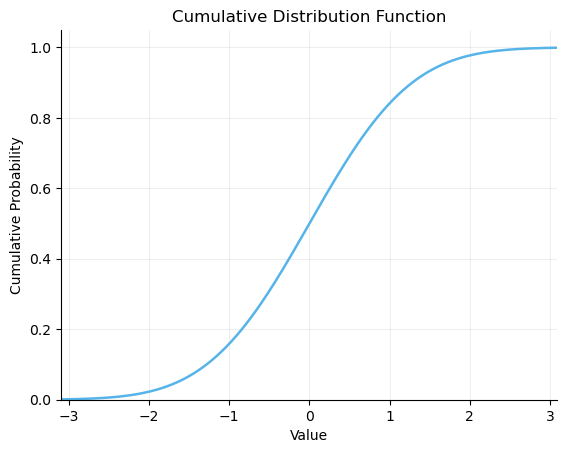

In [35]:
Normal(0, 1).plot(cdf=True)

### The window frames itself
A theoretical curve is drawn on the region where its probability actually lives
rather than its full support, so overlaying it on simulated data does not stretch
the shared axis. Nothing is passed in: `Binomial(100, 0.5)` frames about
`(35, 65)` on its own, while a small `Binomial(10, 0.5)` keeps all of `(0, 10)`.

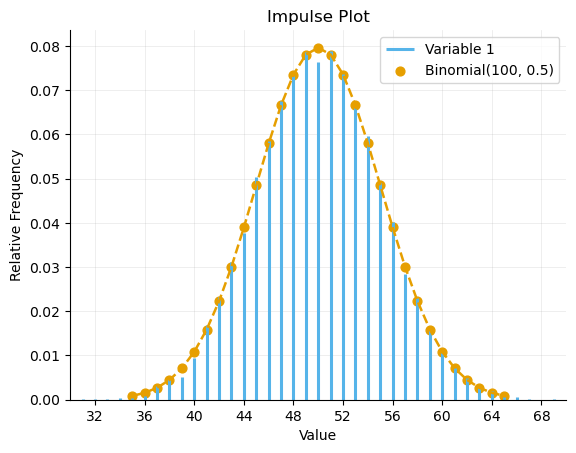

In [36]:
RV(Binomial(100, 0.5)).sim(10000).plot(suggest=False)
Binomial(100, 0.5).plot()

### Shading regions with `shade()`
Chain `.shade()` off a distribution's `.plot()` to fill a tail or interval.
`lt`/`le` set an upper bound, `gt`/`ge` a lower bound.

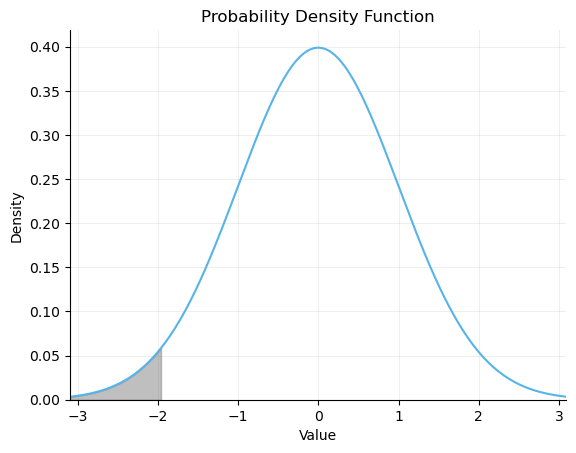

In [37]:
Normal(0, 1).plot().shade(lt=-1.96)

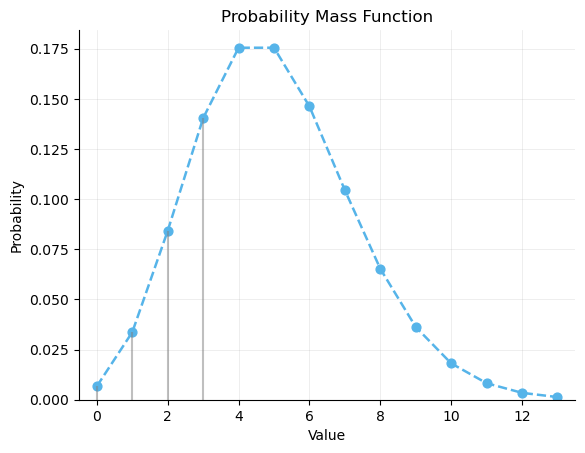

In [38]:
Poisson(5).plot().shade(le=3)

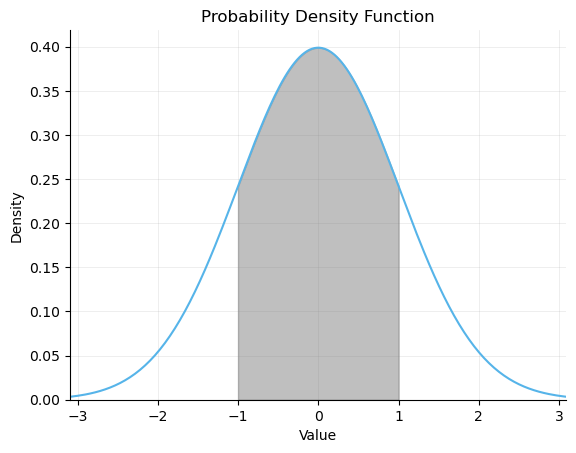

In [39]:
Normal(0, 1).plot().shade(gt=-1, lt=1)

---
## Multivariate distributions
### Two variables, exactly
A distribution's plot of two variables always draws three panels: their joint distribution,
plus each variable's own **exact** marginal beside it. There is no `marginal=` keyword here —
an exact distribution has no reason to want the bare joint panel.

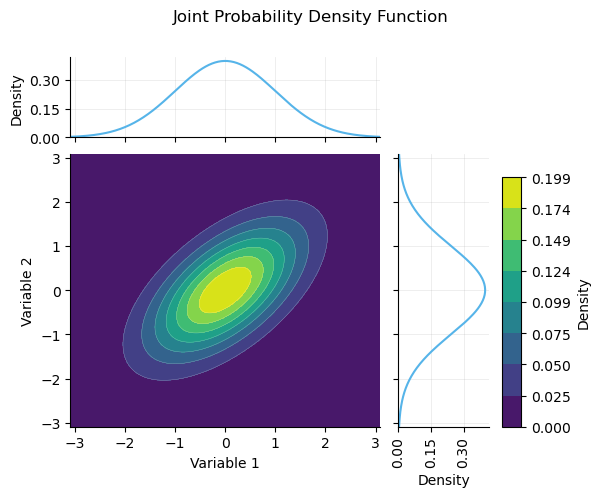

In [40]:
MultivariateNormal(mean=[0, 0], cov=[[1.0, 0.6], [0.6, 1.0]]).plot()

A discrete joint distribution is a grid of probabilities, one cell per possible pair,
with the marginal pmf beside each axis.

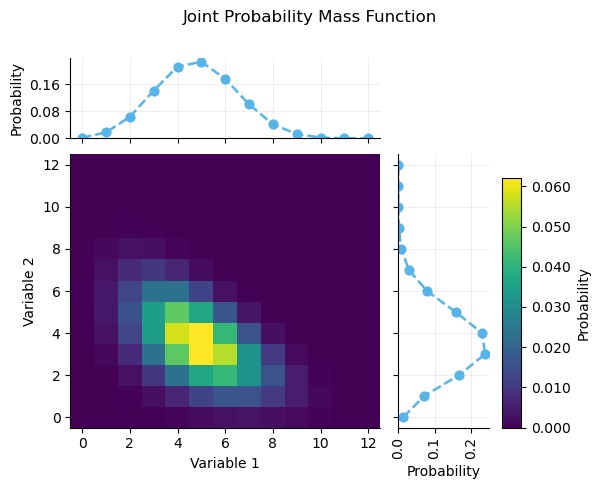

In [41]:
Multinomial(n=12, p=[0.4, 0.3, 0.3]).plot()

### Three or more, and choosing variables
Three or more freely varying variables draw the matrix, titled by what its panels are.
`variables=` picks which to show, numbered from 0: **one** for that variable's own
distribution, **two** for their joint distribution, **three or more** for a matrix of
those. The labels keep the numbers you asked for.

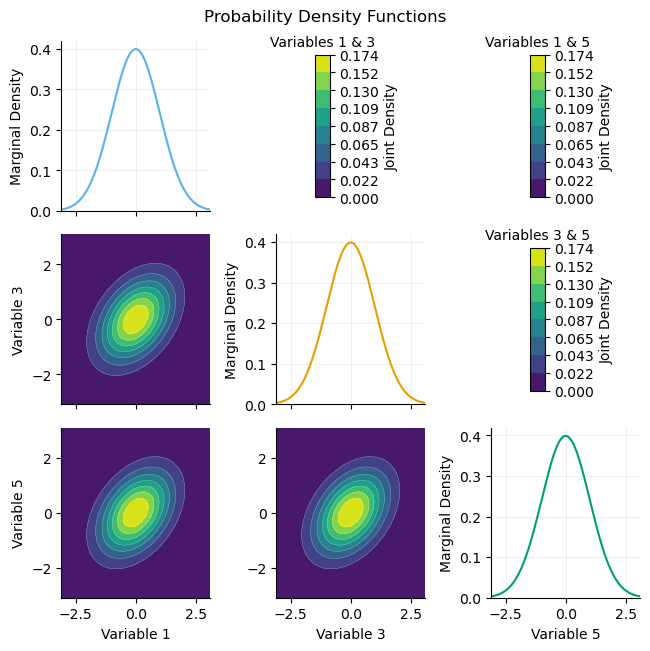

In [42]:
big = MultivariateNormal(mean=[0] * 5,
                        cov=[[1.0 if i == j else 0.4 for j in range(5)]
                             for i in range(5)])
big.plot(variables=[0, 2, 4])  # the 1st, 3rd and 5th

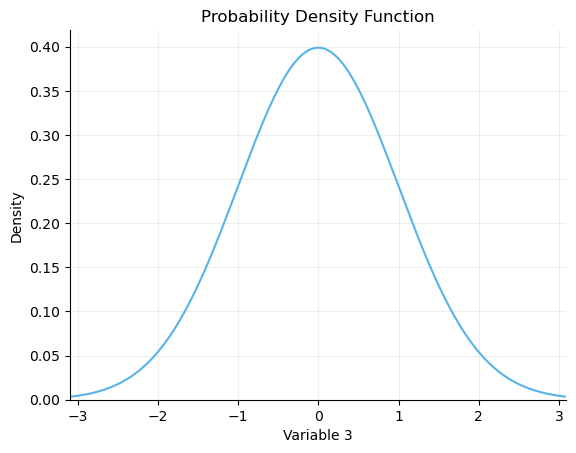

In [43]:
big.plot(variables=2)  # just the 3rd variable's own distribution